In [3]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.layers.normalization import BatchNormalization
import numpy as np

In [6]:
model = Sequential()

# 1st Convolutional Layer
model.add(Conv2D(filters=96, input_shape=(224, 224, 3), kernel_size=(11, 11), strides=(4, 4), padding='valid'))
model.add(Activation('relu'))
# Max Pooling
model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='valid'))

# 2nd Convolutional Layer
model.add(Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), padding='valid'))
model.add(Activation('relu'))
# Max Pooling
model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='valid'))

# 3rd Convolutional Layer
model.add(Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), padding='valid'))
model.add(Activation('relu'))

# 4th Convolutional Layer
model.add(Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), padding='valid'))
model.add(Activation('relu'))

# 5th Convolutional Layer
model.add(Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), padding='valid'))
model.add(Activation('relu'))
# Max Pooling
model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='valid'))

# Fully Connected layer
model.add(Flatten())
# 1st Fully Connected Layer
model.add(Dense(4096, input_shape=(224*224*3,)))
model.add(Activation('relu'))
# Add Dropout to prevent overfitting
model.add(Dropout(0.5))

# 2nd Fully Connected Layer
model.add(Dense(4096))
model.add(Activation('relu'))
# Add Dropout
model.add(Dropout(0.5))

# 3rd Fully Connected Layer
model.add(Dense(1000))
model.add(Activation('softmax'))

model.summary()

# Compile the model
model.compile(loss=keras.losses.categorical_crossentropy, optimizer='adam', metrics=['accuracy'])

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_11 (Conv2D)           (None, 54, 54, 96)        34944     
_________________________________________________________________
activation_14 (Activation)   (None, 54, 54, 96)        0         
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 26, 26, 96)        0         
_________________________________________________________________
conv2d_12 (Conv2D)           (None, 22, 22, 256)       614656    
_________________________________________________________________
activation_15 (Activation)   (None, 22, 22, 256)       0         
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 10, 10, 256)       0         
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 8, 8, 384)         885120    
__________

In [7]:
## MNIST explore
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# load MNIST dataset
from keras.datasets import mnist

from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.optimizers import Adam
from keras.layers.normalization import BatchNormalization
from keras.utils import np_utils
from keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D
# from keras.layers.advanced_activations import LeakyReLU
from keras.preprocessing.image import ImageDataGenerator

#################################################
# Step 1:
# Load the image data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11493376/11490434 [==============================] - 0s 0us/step


In [17]:
X_test.shape

(10000, 28, 28)

In [12]:
y_train[:20]


array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9],
      dtype=uint8)

In [19]:
number_of_classes = 10

y_train = np_utils.to_categorical(y_train, number_of_classes)
y_test = np_utils.to_categorical(y_test, number_of_classes)

In [20]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.], dtype=float32)

In [18]:
# preprocess data
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

X_train/=255
X_test/=255

In [25]:
model = Sequential()

# 1st Convolutional Layer
model.add(Conv2D(filters=32, input_shape=(28, 28, 1), kernel_size=(3, 3), strides=(1, 1), padding='valid'))
model.add(Activation('relu'))
# Max Pooling
model.add(MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='valid'))

# 2nd Convolutional Layer
model.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding='valid'))
model.add(Activation('relu'))
# Max Pooling
model.add(MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='valid'))

# 3rd Convolutional Layer
model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding='valid'))
model.add(Activation('relu'))

# 4th Convolutional Layer
model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding='valid'))
model.add(Activation('relu'))

# Max Pooling
model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='valid'))

# Fully Connected layer
model.add(Flatten())
# 1st Fully Connected Layer
model.add(Dense(512))
model.add(Activation('relu'))
# Add Dropout to prevent overfitting
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(10))
model.add(Activation('softmax'))

model.summary()

# Compile the model
model.compile(loss=keras.losses.categorical_crossentropy, optimizer='adam', metrics=['accuracy'])

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_20 (Conv2D)           (None, 26, 26, 32)        320       
_________________________________________________________________
activation_28 (Activation)   (None, 26, 26, 32)        0         
_________________________________________________________________
max_pooling2d_13 (MaxPooling (None, 24, 24, 32)        0         
_________________________________________________________________
conv2d_21 (Conv2D)           (None, 22, 22, 32)        9248      
_________________________________________________________________
activation_29 (Activation)   (None, 22, 22, 32)        0         
_________________________________________________________________
max_pooling2d_14 (MaxPooling (None, 20, 20, 32)        0         
_________________________________________________________________
conv2d_22 (Conv2D)           (None, 18, 18, 64)        18496     
__________

In [14]:
gen = ImageDataGenerator(rotation_range=8, width_shift_range=0.08, shear_range=0.3,
                         height_shift_range=0.08, zoom_range=0.08)

test_gen = ImageDataGenerator()

In [23]:
# hyoer-parameters
BATCH_SIZE = 64
EPOCHS = 5

In [21]:
train_generator = gen.flow(X_train, y_train, batch_size=BATCH_SIZE)
test_generator = test_gen.flow(X_test, y_test, batch_size=BATCH_SIZE)

In [26]:
model.fit_generator(train_generator, steps_per_epoch=60000//BATCH_SIZE, epochs=EPOCHS, 
                    validation_data=test_generator, validation_steps=10000//BATCH_SIZE)

Epoch 1/5
937/937 [==============================] - 173s 184ms/step - loss: 0.2400 - acc: 0.9240 - val_loss: 0.0492 - val_acc: 0.9848
Epoch 2/5
937/937 [==============================] - 171s 182ms/step - loss: 0.0841 - acc: 0.9742 - val_loss: 0.0304 - val_acc: 0.9899
Epoch 3/5
937/937 [==============================] - 170s 181ms/step - loss: 0.0638 - acc: 0.9803 - val_loss: 0.0358 - val_acc: 0.9902
Epoch 4/5
937/937 [==============================] - 163s 173ms/step - loss: 0.0532 - acc: 0.9836 - val_loss: 0.0197 - val_acc: 0.9936
Epoch 5/5
937/937 [==============================] - 167s 179ms/step - loss: 0.0495 - acc: 0.9849 - val_loss: 0.0227 - val_acc: 0.9934


In [27]:
to_predict = X_test[0]

In [29]:
to_predict.shape

(28, 28, 1)

In [31]:
to_predict = np.expand_dims(to_predict, axis=0)

In [32]:
to_predict.shape

(1, 28, 28, 1)

In [35]:
model.predict_classes(to_predict)

array([7], dtype=int64)

In [36]:
y_test[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.], dtype=float32)

In [37]:
model.save('my_nmist_model.h5')

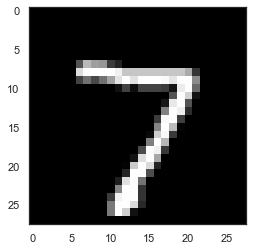

In [45]:
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

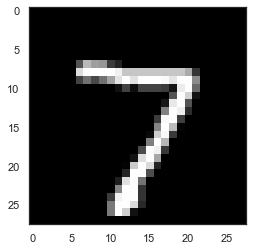

In [46]:
plt.imshow(X_test[0][:,:,0], cmap='gray')
plt.show()